**Exercice 1 : Détection et suppression des doublons**

In [116]:
#Importer les bibliothèques nécessaires
import pandas as pd

In [117]:
# Charger l'ensemble de données Titanic.
titanic = pd.read_csv('titanic_dataset/train.csv')

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [118]:
# Identifiez les lignes en double en vous basant sur toutes les colonnes
titanic_doublons = titanic[titanic.duplicated(keep=False)]
print(titanic_doublons)

Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


In [119]:
# Supprimez les lignes en double présentes dans l'ensemble de données
titanic_sans_doublons = titanic.drop_duplicates()
print(titanic_sans_doublons)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [120]:
# Vérifiez la suppression des doublons en comparant le nombre de lignes avant et après la suppression
print(titanic_sans_doublons.duplicated().sum())

0


-----------

**Exercice 2 : Gestion des valeurs manquantes**

In [121]:
#Importer les bibliothèques nécessaires et importation du dataset
import pandas as pd
from sklearn.impute import SimpleImputer

dfs = pd.read_csv('titanic_dataset/train.csv')

In [122]:
# Identifier les colonnes du jeu de données Titanic comportant des valeurs manquantes
missing_data = dfs.isnull()
print(missing_data.head())

   PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0        False     False   False  False  False  False  False  False   False   
1        False     False   False  False  False  False  False  False   False   
2        False     False   False  False  False  False  False  False   False   
3        False     False   False  False  False  False  False  False   False   
4        False     False   False  False  False  False  False  False   False   

    Fare  Cabin  Embarked  
0  False   True     False  
1  False  False     False  
2  False   True     False  
3  False  False     False  
4  False   True     False  


Explorons différentes stratégies pour gérer les données manquantes, telles que la suppression, l'imputation et le remplissage par une valeur constante.

 - la suppression des lignes contenant des valeurs manquantes avec la methode `dropna()` est une approche simple qui supprime les lignes où au moins une valeur est manquante. Cependant, cela peut entraîner une perte de données importante si de nombreuses lignes contiennent des valeurs manquantes.

 - l'imputation consiste à remplacer les valeurs manquantes par des estimations basées sur des valeurs estimées ou calculées avec la methode `fillna()`

 - Le remplissage par une valeur constante est aussi une technique de gestion de donnée manquante qui consiste à remplacer les données manquantes par une valeur fixe comme `0`, `Inconnu` etc.

In [123]:
# Appliquez chaque stratégie à différentes colonnes en fonction de la nature des données.

# Avec la methode de la suppression
dfs_supp = dfs.dropna(subset=['Age', 'Cabin'])
print(dfs_supp)


     PassengerId  Survived  Pclass  \
1              2         1       1   
3              4         1       1   
6              7         0       1   
10            11         1       3   
11            12         1       1   
..           ...       ...     ...   
871          872         1       1   
872          873         0       1   
879          880         1       1   
887          888         1       1   
889          890         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                              McCarthy, Mr. Timothy J    male  54.0      0   
10                     Sandstrom, Miss. Marguerite Rut  female   4.0      1   
11                            Bonnell, Miss. Elizabeth  female  58.0      0   
..                                                 ...     ...   ... 

In [124]:
# Avec la methode de l'imputation
dfs_imputation = dfs.fillna({'Age': dfs['Age'].mean()})
print(dfs_imputation)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex        Age  \
0                              Braund, Mr. Owen Harris    male  22.000000   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                               Heikkinen, Miss. Laina  female  26.000000   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4                             Allen, Mr. William Henry    male  35.000000   
..                                                 ...     ...        ...   
886 

In [125]:
# La méthode de remplissage par une valeur constante avec simpleImputer
imputer = SimpleImputer(strategy='constant', fill_value='NEANT')
print(imputer.fit_transform(dfs[['Cabin']]))

[['NEANT']
 ['C85']
 ['NEANT']
 ['C123']
 ['NEANT']
 ['NEANT']
 ['E46']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['G6']
 ['C103']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['D56']
 ['NEANT']
 ['A6']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['C23 C25 C27']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['B78']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['D33']
 ['NEANT']
 ['B30']
 ['C52']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['B28']
 ['C83']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['F33']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['F G73']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['C23 C25 C27']
 ['NEANT']
 ['NEANT']
 ['NEANT']
 ['E

-----------

**Exercice 3 : Ingénierie des fonctionnalités**

In [126]:
# Importe la bibliothèque nécessaire 
import pandas as pd
import sklearn as sklearn

In [127]:
# Créez de nouvelles fonctionnalités, telles que Family Size« fromSibSp » Parchet Title« extracted » de la Namecolonne.
dfs['FamilySize'] = dfs['SibSp'] + dfs['Parch'] + 1 
dfs['Title'] = dfs['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(dfs[['FamilySize', 'Title']].head())

   FamilySize Title
0           2    Mr
1           2   Mrs
2           1  Miss
3           2   Mrs
4           1    Mr


<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
C:\Users\USER\AppData\Local\Temp\ipykernel_17208\1775365778.py:3: SyntaxWarning: invalid escape sequence '\.'
  dfs['Title'] = dfs['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [128]:
# Convertissez les variables catégorielles en format numérique à l'aide de techniques telles que l'encodage one-hot ou l'encodage par étiquette.
dfs_encoded = pd.get_dummies(dfs, columns=['Sex', 'Embarked'])
print(dfs_encoded.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  FamilySize Title  Sex_female  Sex_male  \
0         A/5 21171   7.2500   NaN           2    Mr       False      True   
1          PC 17599  71.2833   C85           2   Mrs        True     False   
2  STON/O2. 3101282   7.9250   NaN           1  Miss        True     False   
3            1

In [129]:
# Vous encoderez ici de nouvelles caractéristiques catégorielles (comme le titre), mais ne mettez pas encore à l'échelle les caractéristiques numériques — cela viendra après le traitement des valeurs aberrantes
dfs_encoding = pd.get_dummies(dfs, columns=['Title'])
print(dfs_encoding.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  ... Title_Major Title_Master  Title_Miss  \
0      0         A/5 21171   7.2500  ...       False        False       False   
1      0          PC 17599  71.2833  ...       False        False       False   
2      0  STON/O2. 3101282   7.9250  ...       False        False        True

------

**Exercice 4 : Détection et traitement des valeurs aberrantes**

In [130]:
# Importer les bibliothèques nécessaires
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

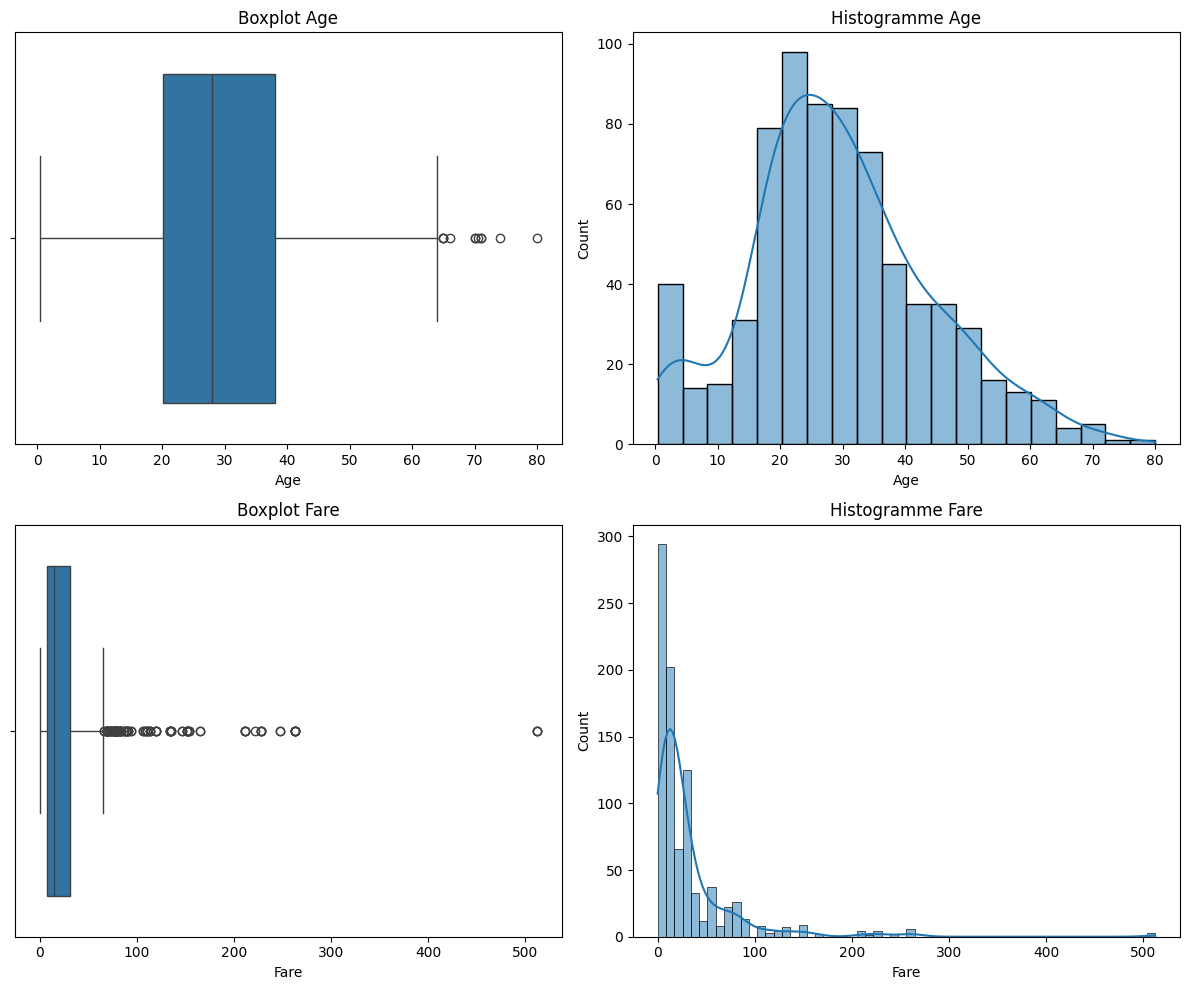

In [131]:
# Visualisation des distributions pour Age et Fare
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(x=dfs['Age'], ax=axes[0, 0]).set_title('Boxplot Age')
sns.histplot(dfs['Age'], kde=True, ax=axes[0, 1]).set_title('Histogramme Age')
sns.boxplot(x=dfs['Fare'], ax=axes[1, 0]).set_title('Boxplot Fare')
sns.histplot(dfs['Fare'], kde=True, ax=axes[1, 1]).set_title('Histogramme Fare')
plt.tight_layout()
plt.show()

In [132]:
# Détection des valeurs aberrantes avec l'IQR et le score Z
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

age_lower, age_upper = iqr_bounds(dfs['Age'])
fare_lower, fare_upper = iqr_bounds(dfs['Fare'])

print('Age IQR bounds:', age_lower, age_upper)
print('Fare IQR bounds:', fare_lower, fare_upper)

outliers_age = dfs[(dfs['Age'] < age_lower) | (dfs['Age'] > age_upper)]
outliers_fare = dfs[(dfs['Fare'] < fare_lower) | (dfs['Fare'] > fare_upper)]
print('Age outliers count:', len(outliers_age))
print('Fare outliers count:', len(outliers_fare))

age_z = (dfs['Age'] - dfs['Age'].mean()) / dfs['Age'].std()
fare_z = (dfs['Fare'] - dfs['Fare'].mean()) / dfs['Fare'].std()

z_age = dfs[np.abs(age_z) > 3]
z_fare = dfs[np.abs(fare_z) > 3]
print('Age Z-score > 3 count:', len(z_age))
print('Fare Z-score > 3 count:', len(z_fare))

Age IQR bounds: -6.6875 64.8125
Fare IQR bounds: -26.724 65.6344
Age outliers count: 11
Fare outliers count: 116
Age Z-score > 3 count: 2
Fare Z-score > 3 count: 20


In [133]:
# Traitement : plafonnement par quantile, transformation logarithmique et suppression
age_q98 = dfs['Age'].quantile(0.98)
age_q99 = dfs['Age'].quantile(0.99)
fare_q98 = dfs['Fare'].quantile(0.98)
fare_q99 = dfs['Fare'].quantile(0.99)

print('Age quantile 0.98:', age_q98, 'quantile 0.99:', age_q99)
print('Fare quantile 0.98:', fare_q98, 'quantile 0.99:', fare_q99)

dfs_capped = dfs.copy()
dfs_capped['Age'] = np.where(dfs_capped['Age'] > age_q98, age_q98, dfs_capped['Age'])
dfs_capped['Fare'] = np.where(dfs_capped['Fare'] > fare_q98, fare_q98, dfs_capped['Fare'])

dfs_log = dfs_capped.copy()
dfs_log['Age_log'] = np.log(dfs_log['Age'].replace(0, np.nan)).fillna(0)
dfs_log['Fare_log'] = np.log(dfs_log['Fare'].replace(0, np.nan)).fillna(0)

dfs_no_outliers = dfs[
    (dfs['Age'] >= age_lower) & (dfs['Age'] <= age_upper) &
    (dfs['Fare'] >= fare_lower) & (dfs['Fare'] <= fare_upper)
]

print('Original rows:', len(dfs))
print('Rows after suppression des outliers:', len(dfs_no_outliers))

Age quantile 0.98: 62.74000000000001 quantile 0.99: 65.87
Fare quantile 0.98: 211.3375 quantile 0.99: 249.00622000000035
Original rows: 891
Rows after suppression des outliers: 603


In [134]:
# Comparaison des statistiques avant et après traitement
print('--- Age ---')
print('Original:\n', dfs['Age'].describe(), '\n')
print('Capped 0.98:\n', dfs_capped['Age'].describe(), '\n')
print('Sans outliers:\n', dfs_no_outliers['Age'].describe(), '\n')

print('--- Fare ---')
print('Original:\n', dfs['Fare'].describe(), '\n')
print('Capped 0.98:\n', dfs_capped['Fare'].describe(), '\n')
print('Sans outliers:\n', dfs_no_outliers['Fare'].describe())

--- Age ---
Original:
 count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64 

Capped 0.98:
 count    714.000000
mean      29.586513
std       14.230056
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       62.740000
Name: Age, dtype: float64 

Sans outliers:
 count    603.000000
mean      28.269900
std       13.468892
min        0.420000
25%       20.000000
50%       28.000000
75%       36.000000
max       64.000000
Name: Age, dtype: float64 

--- Fare ---
Original:
 count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64 

Capped 0.98:
 count    891.000000
mean      30.678483
std       39.904946
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      211.337

C:\Users\USER\AppData\Local\Temp\ipykernel_17208\2347120249.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([dfs['Age'].dropna(), dfs_capped['Age'].dropna()], labels=['Original', 'Capped'])
C:\Users\USER\AppData\Local\Temp\ipykernel_17208\2347120249.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([dfs['Fare'].dropna(), dfs_capped['Fare'].dropna()], labels=['Original', 'Capped'])


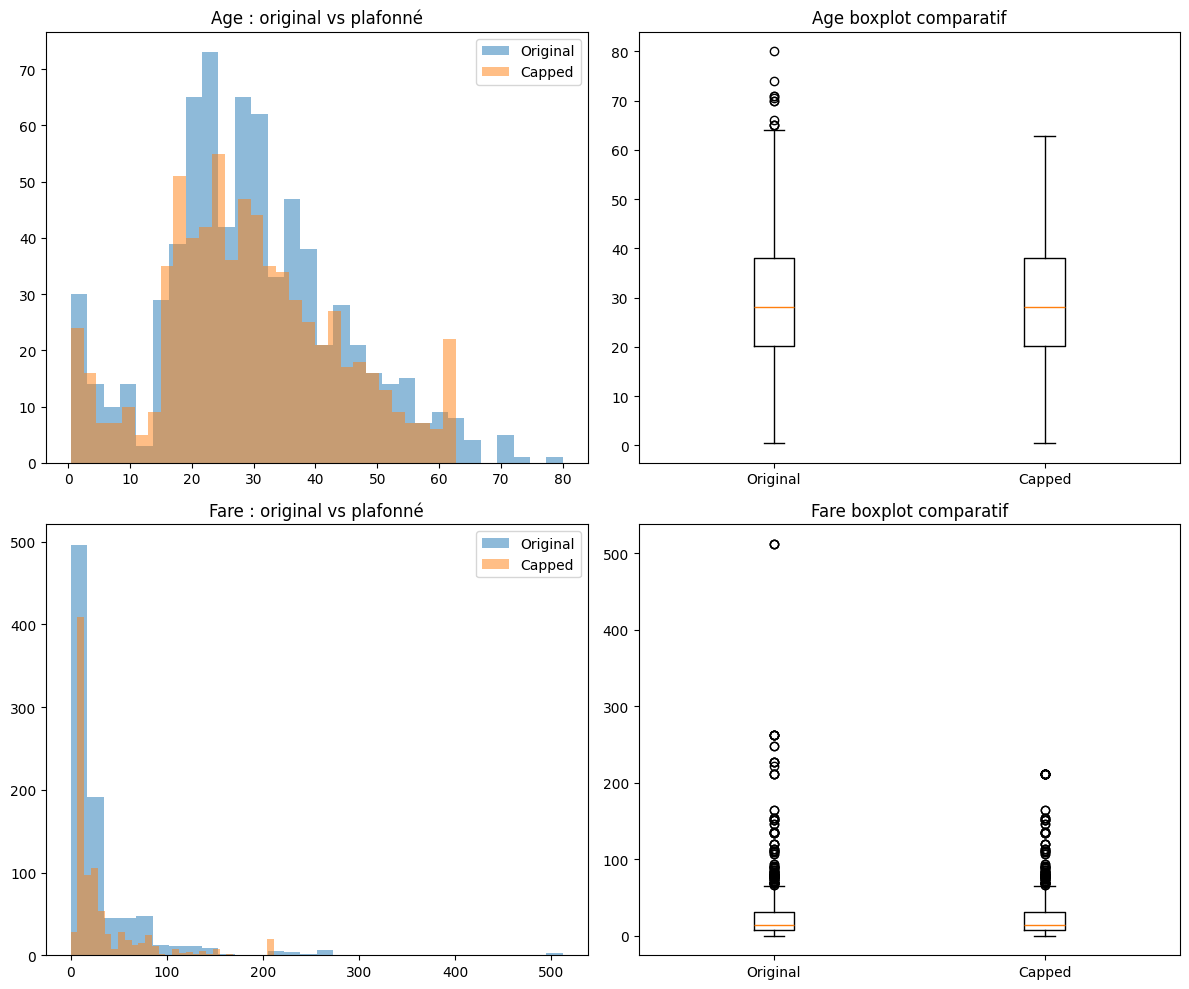

In [135]:
# Visualisation comparative des distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(dfs['Age'], bins=30, alpha=0.5, label='Original')
axes[0, 0].hist(dfs_capped['Age'], bins=30, alpha=0.5, label='Capped')
axes[0, 0].set_title('Age : original vs plafonné')
axes[0, 0].legend()

axes[0, 1].boxplot([dfs['Age'].dropna(), dfs_capped['Age'].dropna()], labels=['Original', 'Capped'])
axes[0, 1].set_title('Age boxplot comparatif')

axes[1, 0].hist(dfs['Fare'], bins=30, alpha=0.5, label='Original')
axes[1, 0].hist(dfs_capped['Fare'], bins=30, alpha=0.5, label='Capped')
axes[1, 0].set_title('Fare : original vs plafonné')
axes[1, 0].legend()

axes[1, 1].boxplot([dfs['Fare'].dropna(), dfs_capped['Fare'].dropna()], labels=['Original', 'Capped'])
axes[1, 1].set_title('Fare boxplot comparatif')

plt.tight_layout()
plt.show()

In [136]:
# Affichage des transformations logarithmiques
print('Age_log min/max:', dfs_log['Age_log'].min(), dfs_log['Age_log'].max())
print('Fare_log min/max:', dfs_log['Fare_log'].min(), dfs_log['Fare_log'].max())

Age_log min/max: -0.8675005677047231 4.138999202762532
Fare_log min/max: 0.0 5.353456381663085


-----

**Exercice 5 : Standardisation et normalisation des données**

In [137]:
# importer les bibliothèques nécessaires
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [138]:
# Utilisez StandardScaler (moyenne = 0, écart-type = 1) après le traitement des valeurs aberrantes
dfs_clean = dfs_capped.copy()
dfs_scaler = dfs_clean.copy()
dfs_scaler[['Age', 'Fare']] = StandardScaler().fit_transform(dfs_scaler[['Age', 'Fare']])
print(dfs_scaler[['Age', 'Fare']].head())

        Age      Fare
0 -0.533507 -0.587437
1  0.591662  1.018110
2 -0.252215 -0.570512
3  0.380693  0.562189
4  0.380693 -0.567378


In [139]:
# Utilisez MinMaxScaler (plage [0, 1]) pour les caractéristiques asymétriques ou bornées après traitement des outliers.
dfs_minmax = dfs_clean.copy()
minmax_scaler = MinMaxScaler()
dfs_minmax[['Age', 'Fare']] = minmax_scaler.fit_transform(dfs_minmax[['Age', 'Fare']])
print(dfs_minmax[['Age', 'Fare']].head())

        Age      Fare
0  0.346277  0.034305
1  0.603017  0.337296
2  0.410462  0.037499
3  0.554878  0.251257
4  0.554878  0.038091


---------

**Exercice 6 : Encodage des caractéristiques**

In [140]:
# Importer les bibliothèques nécessaires
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

In [141]:
# Identifier les colonnes catégorielles pertinentes à encoder (exclure Name, Ticket, Cabin car elles sont moins utiles ici)
categorical_cols = ['Sex', 'Embarked', 'Title']
print('Colonnes catégorielles sélectionnées pour l’encodage :', categorical_cols)

Colonnes catégorielles sélectionnées pour l’encodage : ['Sex', 'Embarked', 'Title']


In [142]:
# Appliquer : Encodage one-hot pour les variables nominales pertinentes.
encoder_hot = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder_hot.fit_transform(dfs[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder_hot.get_feature_names_out(categorical_cols), index=dfs.index)
print(encoded_df.head())

# Fusionner les colonnes encodées avec l'ensemble de données principal.
dfs_final = pd.concat([dfs.drop(columns=categorical_cols), encoded_df], axis=1)
print(dfs_final.head())

   Sex_male  Embarked_Q  Embarked_S  Embarked_nan  Title_Col  Title_Countess  \
0       1.0         0.0         1.0           0.0        0.0             0.0   
1       0.0         0.0         0.0           0.0        0.0             0.0   
2       0.0         0.0         1.0           0.0        0.0             0.0   
3       0.0         0.0         1.0           0.0        0.0             0.0   
4       1.0         0.0         1.0           0.0        0.0             0.0   

   Title_Don  Title_Dr  Title_Jonkheer  Title_Lady  Title_Major  Title_Master  \
0        0.0       0.0             0.0         0.0          0.0           0.0   
1        0.0       0.0             0.0         0.0          0.0           0.0   
2        0.0       0.0             0.0         0.0          0.0           0.0   
3        0.0       0.0             0.0         0.0          0.0           0.0   
4        0.0       0.0             0.0         0.0          0.0           0.0   

   Title_Miss  Title_Mlle  Title

------

**Exercice 7 : Transformation des données pour la caractéristique Âge**

In [143]:
# Importer les bibliothèques nécessaires
import pandas as pd

In [144]:
# À utiliser pd.cut() pour créer des catégories correspondant aux étapes de la vie (par exemple enfant, adolescent, adulte, senior)
dfs['AgeGroup'] = pd.cut(dfs['Age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])
print(dfs[['Age', 'AgeGroup']].head())

# Encodage one-hot de la nouvelle variable AgeGroup
dfs_agegroup = pd.get_dummies(dfs['AgeGroup'], prefix='AgeGroup')
dfs = pd.concat([dfs, dfs_agegroup], axis=1)
print(dfs_agegroup.head())
print(dfs[['Age', 'AgeGroup'] + dfs_agegroup.columns.tolist()].head())

    Age AgeGroup
0  22.0    Adult
1  38.0    Adult
2  26.0    Adult
3  35.0    Adult
4  35.0    Adult
   AgeGroup_Child  AgeGroup_Teen  AgeGroup_Adult  AgeGroup_Senior
0           False          False            True            False
1           False          False            True            False
2           False          False            True            False
3           False          False            True            False
4           False          False            True            False
    Age AgeGroup  AgeGroup_Child  AgeGroup_Teen  AgeGroup_Adult  \
0  22.0    Adult           False          False            True   
1  38.0    Adult           False          False            True   
2  26.0    Adult           False          False            True   
3  35.0    Adult           False          False            True   
4  35.0    Adult           False          False            True   

   AgeGroup_Senior  
0            False  
1            False  
2            False  
3            Fa